# Training a U-Net with BiaPy

On day 2 we used StarDist and Cellpose, trained by other people. Today we train our own,
because we want something nobody made a model for: the nuclei, from the **actin**
(phalloidin) channel. If that works we can stop staining DNA and use that channel for
something else.

We get a model running first and look at what it did. The details of how it works come
afterwards, once there is something to point at.

The images come from `data_collection_IDR_stardist.ipynb` — you have them as a zip, so you
do not need to run that notebook. Use the BiaPy kernel (`nlbi26-day3-biapy`).

In [2]:
from pathlib import Path
import shutil
import random

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import Image, display

from skimage.io import imread
from skimage.measure import label as connected_components
from skimage.segmentation import find_boundaries
from scipy.ndimage import distance_transform_edt

## 1. The data

Unzip `training_data` next to this notebook. Two folders with matching file names:
`images/` is the phalloidin channel, `labels/` are the nuclei StarDist found in the DAPI
channel. Open both in the file browser on the left and check that the names match.

In [ ]:
DATA = Path('training_data')

image_files = sorted((DATA / 'images').glob('*.tif'))
label_files = sorted((DATA / 'labels').glob('*.tif'))

print(len(image_files), 'images,', len(label_files), 'label images')

In [ ]:
image = imread(DATA / 'images' / '1895787.tif')
labels = imread(DATA / 'labels' / '1895787.tif')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap='gray', vmin=np.percentile(image, 1), vmax=np.percentile(image, 99.8))
axes[0].set_title('phalloidin')
axes[1].imshow(np.ma.masked_equal(labels, 0), cmap='tab20', interpolation='nearest')
axes[1].set_title(f'labels: {labels.max()} nuclei')
for ax in axes:
    ax.axis('off')

Nobody checked all 100 label images, so count the nuclei in each one before we train on them.

In [ ]:
counts = pd.Series({f.name: imread(f).max() for f in label_files})

print(counts.describe().round(1))
print()
print('empty:', list(counts[counts == 0].index))

Two images have no nuclei. They teach the network nothing and they break the scores later
(you cannot ask how many of the nuclei we found when there are none), so we drop them.

## 2. Splitting the data

Three piles:

- **training** — what the network learns from
- **validation** — checked every epoch, to see whether it is still improving or has started
  memorising the training images
- **test** — touched once, at the end. It is the only honest number you get, and the moment
  you use it to pick a setting it stops being one.

Train and test become folders. Validation is not a folder: BiaPy takes a fraction of the
training images.

In [ ]:
TEST_FRACTION = 0.2
VALIDATION_FRACTION = 0.2

usable = [f.stem for f in label_files if imread(f).max() > 0]

random.seed(42)          # fixed, so everyone gets the same split
random.shuffle(usable)

n_test = round(len(usable) * TEST_FRACTION)
test_ids = usable[:n_test]
train_ids = usable[n_test:]

print(len(train_ids), 'train,', len(test_ids), 'test')

In [ ]:
DATASET = Path('dataset')

# Wipe it first. Otherwise, if you change the split and run this again, images from the old
# split stay behind and a test image quietly ends up in the training set as well.
if DATASET.exists():
    shutil.rmtree(DATASET)

for split, ids in [('train', train_ids), ('test', test_ids)]:
    for kind in ('images', 'labels'):
        folder = DATASET / split / kind
        folder.mkdir(parents=True, exist_ok=True)
        for image_id in ids:
            shutil.copy(DATA / kind / f'{image_id}.tif', folder / f'{image_id}.tif')

print(len(list((DATASET / 'train' / 'images').glob('*.tif'))), 'files in train')
print(len(list((DATASET / 'test' / 'images').glob('*.tif'))), 'files in test')

Open `dataset/` in the file browser. Check that `train/images/` and `train/labels/` hold the
same names, and that nothing appears in both `train/` and `test/`.

We split randomly, which is fine here: different wells, different fields. When would that be
wrong? Think about frames of a time lapse, slices through one organoid, or five fields from
each of four patients.

## 3. The settings

BiaPy reads a YAML file. We take the template BiaPy publishes for 2D instance segmentation,
change a few settings from Python, and write it back out.

In [ ]:
patch_size = 256     # the network trains on crops of this size, not whole images
epochs = 20          # one epoch is one pass over the training images
batch_size = 8       # crops through the network at once

# Start with the simplest thing we can ask of the network: for every pixel, is this a
# nucleus or not. Section 7 is about what else you could ask it.
data_channels = ['F']
job_name = 'run1_foreground'     # each run gets its own name, so nothing is overwritten
run_id = 1

output_path = 'training_output'

In [ ]:
from urllib.request import urlretrieve

template = Path('2d_instance_segmentation.yaml')
if not template.exists():
    urlretrieve(
        'https://raw.githubusercontent.com/BiaPyX/BiaPy/v3.7.1/templates/'
        'instance_segmentation/2d_instance_segmentation.yaml',
        template,
    )

print(template.read_text())

Read that file into a dictionary, change what we need, save it under a new name. The
template stays untouched so you can always start over.

In [ ]:
config = yaml.safe_load(template.read_text())

# what the network has to predict
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = data_channels

# where the data is
config['DATA']['TRAIN']['PATH'] = 'dataset/train/images'
config['DATA']['TRAIN']['GT_PATH'] = 'dataset/train/labels'
config['DATA']['TEST']['PATH'] = 'dataset/test/images'
config['DATA']['TEST']['GT_PATH'] = 'dataset/test/labels'

# validation comes out of the training images
config['DATA']['VAL']['FROM_TRAIN'] = True
config['DATA']['VAL']['SPLIT_TRAIN'] = VALIDATION_FRACTION

# PATCH_SIZE has to be a string, that is how BiaPy reads it
config['DATA']['PATCH_SIZE'] = f'({patch_size}, {patch_size}, 1)'
config['TRAIN']['EPOCHS'] = epochs
config['TRAIN']['BATCH_SIZE'] = batch_size

run_config = Path('2d_instance_segmentation_config.yaml')
run_config.write_text(yaml.safe_dump(config, sort_keys=False))

print(run_config.read_text())

Worth reading line by line 
`AUGMENTOR` shows the network rotated and flipped copies of the training images.
`PATIENCE` stops early when the validation loss has not improved for that many epochs.
`LR` is how big a step the network takes at each update. `TEST.ENABLE` runs the finished
model on the test set.

## 4. Train

A few minutes on a GPU. Watch the `loss` and `IoU` on the per-epoch lines.

In [ ]:
from biapy import BiaPy

biapy = BiaPy(config=str(run_config), result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')
biapy.run_job()

In [ ]:
results = Path(output_path) / job_name / 'results' / f'{job_name}_{run_id}'

for item in sorted(results.iterdir()):
    print(item.name)

## 5. Did the training go well?

BiaPy drew the curves for us and put them in `charts/`.

In [ ]:
for chart in sorted((results / 'charts').glob('*.png')):
    display(Image(str(chart)))

The loss is how wrong the network is, so down is good, and the gap between the two curves is
the interesting part. Still falling at the last epoch means train longer. Flat for a while
means it has learned what it can. Training loss falling while validation loss rises means it
is memorising the training images — stop earlier, augment more, or get more data. Jumping up
and down means the learning rate is too high.

Look at your own two curves and decide which of those four you are seeing, before changing
anything.

The IoU plot is the overlap between what the network predicts and the target, per channel.

## 6. What does it predict?

`TEST.ENABLE` was on, so BiaPy already ran the model on the 20 test images.

In [ ]:
predictions = results / 'per_image_instances'

for image_id in test_ids[:3]:
    test_image = imread(DATASET / 'test' / 'images' / f'{image_id}.tif')
    test_labels = imread(DATASET / 'test' / 'labels' / f'{image_id}.tif')
    predicted = imread(predictions / f'{image_id}.tif')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(test_image, cmap='gray',
                   vmin=np.percentile(test_image, 1), vmax=np.percentile(test_image, 99.8))
    axes[0].set_title(image_id)
    axes[1].imshow(np.ma.masked_equal(test_labels, 0), cmap='tab20', interpolation='nearest')
    axes[1].set_title(f'labels: {test_labels.max()} nuclei')
    axes[2].imshow(np.ma.masked_equal(predicted, 0), cmap='tab20', interpolation='nearest')
    axes[2].set_title(f'prediction: {predicted.max()} objects')
    for ax in axes:
        ax.axis('off')
    plt.show()

Zoom in on a dense patch and look for two nuclei that got one colour. Hold on to that —
section 7 is about why it happens.

"Looks alright" is not a result though, so first let's put numbers on it.

BiaPy already compared its prediction with the test labels and wrote a CSV: one row per test
image, and every score at three levels of strictness (`0.3 TH`, `0.5 TH`, `0.75 TH`).

In [ ]:
scores = pd.read_csv(results / 'test_results_metrics.csv')

list(scores.columns)

Start with the simplest score: how many objects. If your question is how many cells are in
a well, this may be all you need.

In [ ]:
counts = scores[['file', '0.5 TH n_true', '0.5 TH n_pred']].copy()
counts.columns = ['image', 'nuclei in the labels', 'objects found']

print(counts.head(10))
print()
print(counts.sum(numeric_only=True))

But a count says nothing about *where* the objects are. To decide whether a predicted object
*is* a labelled one, compare their pixels: **intersection over union**, the pixels they share
divided by the pixels they cover together. 1.0 is identical, 0.5 is a reasonable overlap,
0.0 is no overlap at all.

Text(0.5, 0.98, 'IoU = 977 / 2905 = 0.34')

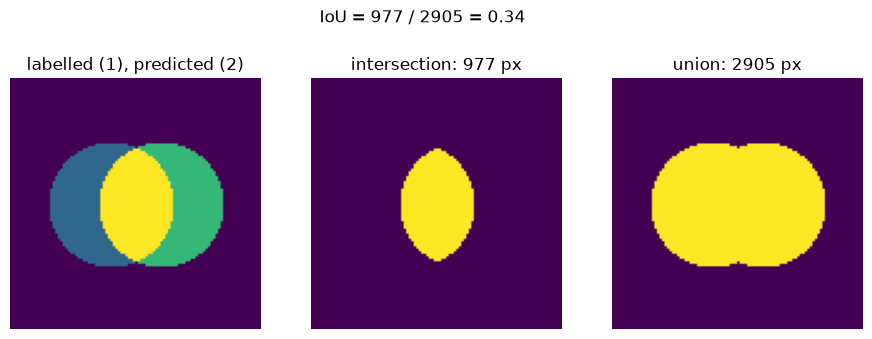

In [3]:
yy, xx = np.mgrid[:100, :100]
labelled = (yy - 50) ** 2 + (xx - 40) ** 2 < 25 ** 2
predicted = (yy - 50) ** 2 + (xx - 60) ** 2 < 25 ** 2

intersection = (labelled & predicted).sum()
union = (labelled | predicted).sum()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, img, title in zip(
        axes,
        [labelled + 2 * predicted, labelled & predicted, labelled | predicted],
        ['labelled (1), predicted (2)', f'intersection: {intersection} px', f'union: {union} px']):
    ax.imshow(img, cmap='viridis')
    ax.set_title(title)
    ax.axis('off')

fig.suptitle(f'IoU = {intersection} / {union} = {intersection / union:.2f}')

**Try it:** move the predicted circle closer (`xx - 60` → `xx - 50`) or make it bigger
(`25 ** 2` → `35 ** 2`) and re-run. How far off can a prediction be and still reach 0.5?

Two objects count as the same when their IoU is above a threshold — 0.5 by convention.
Then every object is one of three things:

- **TP** — a predicted object that matches a labelled one
- **FP** — a predicted object that matches nothing: invented
- **FN** — a labelled object that nothing matches: missed

**precision** = TP / (TP + FP), of what it found, how much is real.
**recall** = TP / (TP + FN), of what is there, how much did it find.
**F1** combines the two. These are the `0.5 TH` columns.

In [4]:
at_05 = scores[['file', '0.5 TH tp', '0.5 TH fp', '0.5 TH fn',
                '0.5 TH precision', '0.5 TH recall', '0.5 TH f1',
                '0.5 TH mean_matched_score']].copy()
at_05.columns = ['image', 'TP', 'FP', 'FN', 'precision', 'recall', 'F1', 'mean matched IoU']

print(at_05.round(2).head(10))
print()
print(at_05.mean(numeric_only=True).round(2))

NameError: name 'scores' is not defined

Which is lower, precision or recall? Go back to the pictures above — what does that look
like in the image?

`mean matched IoU` is the average overlap of the objects that did match. A model can have a
good F1 and a mediocre matched IoU. What kind of mistake is that?

In [ ]:
# the same F1, at three levels of strictness
scores[['0.3 TH f1', '0.5 TH f1', '0.75 TH f1']].mean().round(2)

An F1 that holds up at 0.3 but collapses at 0.75 means the model finds the right nuclei with
sloppy outlines. Which of those matters depends on your question: counting cells needs the
first, measuring nuclear size needs the second.

## 7. Now the detail: what did we actually ask the network to predict?

Back to the nuclei that shared a colour.

A U-Net takes an image and returns an image. It cannot output "nucleus 17" — the numbers in
the label image are arbitrary, and nothing tells the network that this blob should be 17 and
the next one 18. So BiaPy turns the labels into target images the network *can* learn, and
rebuilds the objects from the prediction afterwards. Those targets are the **data channels**
we set in section 3, and `['F']` was the simplest of them.

Let's build them by hand on a crop with a few touching nuclei.

In [ ]:
# Change these to look somewhere else
y, x, size = 160, 480, 140

crop_labels = imread(DATASET / 'train' / 'labels' / '1895787.tif')[y:y + size, x:x + size]

n_nuclei = len(np.unique(crop_labels)) - 1
print(n_nuclei, 'nuclei in this crop')

**F** is what we trained on: for every pixel, nucleus or not. To turn that back into objects
you look for connected blobs of foreground pixels.

In [ ]:
foreground = crop_labels > 0
blobs = connected_components(foreground)

print('nuclei in the labels   :', n_nuclei)
print('blobs in the foreground:', blobs.max())

Fewer blobs than nuclei. Two nuclei that touch share a border, so their foreground pixels are
one blob — and one blob is one object. Even a *perfect* foreground prediction cannot separate
them. That is what you saw in section 6, and it is a limit of the target, not of the training.

How often does it happen here?

In [ ]:
total_nuclei = total_blobs = 0
for f in sorted((DATASET / 'train' / 'labels').glob('*.tif')):
    lab = imread(f)
    total_nuclei += lab.max()
    total_blobs += connected_components(lab > 0).max()

lost = total_nuclei - total_blobs
print(f'{total_nuclei} nuclei -> {total_blobs} blobs')
print(f'{lost} nuclei ({100 * lost / total_nuclei:.0f}%) merged into a neighbour')

The fix: also ask the network for the **outline** of each nucleus — channel **C**. Then we
can cut the blobs apart along the borders.

In [ ]:
contour = find_boundaries(crop_labels, mode='thick')
separated = connected_components(foreground & ~contour)

print('nuclei in the labels           :', n_nuclei)
print('blobs in the foreground        :', blobs.max())
print('blobs after cutting the contour:', separated.max())

BiaPy does not simply subtract the contour — it uses it to place one seed per nucleus and
grows the seeds back out with a watershed, so the nuclei keep their real size. But the reason
it works is what you just saw.

A third option, **D**: predict how far each pixel is from the edge of its nucleus. Every
nucleus gets its own peak, even when two of them touch.

In [ ]:
distance = distance_transform_edt(foreground & ~contour)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(np.ma.masked_equal(crop_labels, 0), cmap='tab20', interpolation='nearest')
axes[0].set_title(f'labels: {n_nuclei} nuclei')
axes[1].imshow(foreground, cmap='gray')
axes[1].set_title('F: foreground')
axes[2].imshow(contour, cmap='gray')
axes[2].set_title('C: contour')
axes[3].imshow(distance, cmap='magma')
axes[3].set_title('D: distance to the edge')
for ax in axes:
    ax.axis('off')

The left panel is what we have. The other three are what the network can be asked to produce,
all derived from the labels. The input is always the phalloidin image.

BiaPy has a dozen more channels (centre points, flow fields, affinities, radial distances).
Open `train_F_instance_channels/` in the run folder: those are the targets BiaPy built from
our labels for run 1, the same thing we just did by hand.

## 8. Run 2: add the contour

One setting changes. Everything else stays the same, so whatever we see is caused by the
channel.

In [ ]:
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = ['F', 'C']
job_name = 'run2_foreground_contour'

run_config.write_text(yaml.safe_dump(config, sort_keys=False))

print(config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'], '->', job_name)

In [ ]:
biapy = BiaPy(config=str(run_config), result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')
biapy.run_job()

In [ ]:
run1 = Path(output_path) / 'run1_foreground' / 'results' / 'run1_foreground_1'
run2 = Path(output_path) / 'run2_foreground_contour' / 'results' / 'run2_foreground_contour_1'

scores1 = pd.read_csv(run1 / 'test_results_metrics.csv')
scores2 = pd.read_csv(run2 / 'test_results_metrics.csv')

interesting = ['0.5 TH n_true', '0.5 TH n_pred', '0.5 TH tp', '0.5 TH fp', '0.5 TH fn',
               '0.5 TH precision', '0.5 TH recall', '0.5 TH f1', '0.5 TH mean_matched_score']

pd.DataFrame({
    'F': scores1[interesting].mean(),
    'F + C': scores2[interesting].mean(),
}).round(2)

In [ ]:
image_id = test_ids[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(np.ma.masked_equal(imread(DATASET / 'test' / 'labels' / f'{image_id}.tif'), 0),
               cmap='tab20', interpolation='nearest')
axes[0].set_title('labels')

for ax, run, name in zip(axes[1:], [run1, run2], ['F', 'F + C']):
    predicted = imread(run / 'per_image_instances' / f'{image_id}.tif')
    ax.imshow(np.ma.masked_equal(predicted, 0), cmap='tab20', interpolation='nearest')
    ax.set_title(f'{name}: {predicted.max()} objects')

for ax in axes:
    ax.axis('off')

Did the contour change the *number* of objects, their *outlines*, or both — and which column
tells you that? Did FN go down? That is where the merged nuclei were hiding.

Both runs got 20 epochs. Two channels is a harder job than one, so open run 2's charts and
see whether it had finished learning.

## 9. If you have time

Each of these is one line, then re-run the config cell, the training cell and the scoring
cells. Give every run its own `job_name`. They take as long as the runs above, so pick one
or two.

```python
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = ['F', 'D']   # distance instead of contour
config['TRAIN']['EPOCHS'] = 60                                    # if the loss was still falling
config['AUGMENTOR']['ENABLE'] = False                             # it is on in the template
config['DATA']['PATCH_SIZE'] = '(128, 128, 1)'                    # smaller crops, less context
config['MODEL']['ARCHITECTURE'] = 'resunet'                       # a different network
```

The last one is what people try first and it is rarely where the gain is. Compare it with
what the contour channel did.

And the question worth asking before any of them: train on 20, 40 and all 78 images
(`train_ids = train_ids[:20]`, then re-run the copy cell) and plot F1 against the number of
training images. If that curve is still rising, annotating more images beats every setting
on this page.